# LSTM Baseline Model: At-Risk Student Prediction
## Bias-Aware Early Warning System for Higher Education

This notebook trains an LSTM model to predict at-risk students within the first 25% of course completion.

**Inputs:**
- `features_temporal.npy` - Weekly VLE engagement sequences (32,593 x 10 x 5)
- `features_static.csv` - Static features + protected attributes + target

**Outputs:**
- `models/lstm_baseline.pt` - Trained model
- `data/processed/predictions_baseline.csv` - Test predictions for fairness analysis

**Target:** AUC ROC > 0.80

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import json
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import warnings

# Filter warnings after imports
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.2.2
Device: cpu


In [2]:
# Paths
DATA_DIR = Path("../data/processed")
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Model directory: {MODEL_DIR}")

Data directory: ../data/processed
Model directory: ../models


## 2. Load Data

In [3]:
# Load temporal features
X_temporal = np.load(DATA_DIR / 'features_temporal.npy')
print(f"Temporal features shape: {X_temporal.shape}")

# Load static features
static_df = pd.read_csv(DATA_DIR / 'features_static.csv')
print(f"Static features shape: {static_df.shape}")

# Load metadata
with open(DATA_DIR / 'feature_metadata.json', 'r') as f:
    metadata = json.load(f)

print(f"\nTemporal features: {metadata['temporal_features']['feature_names']}")
print(f"Static feature columns: {metadata['static_features']['feature_columns']}")

Temporal features shape: (32593, 10, 5)
Static features shape: (32593, 24)

Temporal features: ['total_clicks', 'active_days', 'n_sessions', 'activity_types', 'avg_daily_clicks']
Static feature columns: ['gender_encoded', 'age_band_encoded', 'disability_encoded', 'education_encoded', 'imd_band_encoded', 'num_of_prev_attempts', 'studied_credits', 'n_assessments_submitted', 'avg_score', 'min_score', 'max_score', 'avg_days_early', 'std_score', 'submission_rate']


In [4]:
# Extract components
feature_cols = metadata['static_features']['feature_columns']
protected_cols = metadata['static_features']['protected_columns']
id_cols = metadata['static_features']['id_columns']

# Static features for model
X_static = static_df[feature_cols].values

# Target variable
y = static_df['at_risk'].values

# Protected attributes (for fairness analysis)
protected_attrs = static_df[protected_cols].copy()

# Student identifiers
student_keys = static_df['student_key'].values
course_ids = static_df['code_module'] + '_' + static_df['code_presentation']

print(f"X_temporal: {X_temporal.shape}")
print(f"X_static: {X_static.shape}")
print(f"y: {y.shape} (at-risk rate: {y.mean():.1%})")
print(f"Protected attributes: {protected_cols}")

X_temporal: (32593, 10, 5)
X_static: (32593, 14)
y: (32593,) (at-risk rate: 52.8%)
Protected attributes: ['gender', 'region', 'imd_band_imputed', 'age_band', 'disability']


## 3. Data Preprocessing

In [5]:
# Check for NaN values
print("NaN values in static features:")
nan_counts = pd.DataFrame(X_static, columns=feature_cols).isnull().sum()
print(nan_counts[nan_counts > 0])

# Fill NaN values with 0 (submission_rate for GGG_2014B students)
X_static = np.nan_to_num(X_static, nan=0.0)
print(f"\nAfter filling NaN: {np.isnan(X_static).sum()} NaN values")

NaN values in static features:
submission_rate    833
dtype: int64

After filling NaN: 0 NaN values


In [6]:
# Normalize temporal features
# Reshape to (n_samples * n_timesteps, n_features) for scaling
n_samples, n_timesteps, n_temp_features = X_temporal.shape
X_temporal_flat = X_temporal.reshape(-1, n_temp_features)

temporal_scaler = StandardScaler()
X_temporal_scaled = temporal_scaler.fit_transform(X_temporal_flat)
X_temporal_scaled = X_temporal_scaled.reshape(n_samples, n_timesteps, n_temp_features)

print(f"Temporal features scaled: mean={X_temporal_scaled.mean():.4f}, std={X_temporal_scaled.std():.4f}")

Temporal features scaled: mean=-0.0000, std=1.0000


In [7]:
# Normalize static features
static_scaler = StandardScaler()
X_static_scaled = static_scaler.fit_transform(X_static)

print(f"Static features scaled: mean={X_static_scaled.mean():.4f}, std={X_static_scaled.std():.4f}")

Static features scaled: mean=0.0000, std=1.0000


## 4. Train/Validation/Test Split (Course-Stratified)

In [8]:
# Create combined stratification key: course + target
# This ensures each course-target combination is proportionally represented
strat_key = course_ids.astype(str) + '_' + y.astype(str)

print(f"Unique stratification groups: {strat_key.nunique()}")
print("\nSample distribution by course:")
print(course_ids.value_counts().head(10))

Unique stratification groups: 44

Sample distribution by course:
CCC_2014J    2498
FFF_2014J    2365
BBB_2014J    2292
FFF_2013J    2283
BBB_2013J    2237
DDD_2013J    1938
CCC_2014B    1936
DDD_2014J    1803
BBB_2013B    1767
FFF_2013B    1614
Name: count, dtype: int64


In [9]:
# First split: train+val (85%) vs test (15%)
indices = np.arange(len(y))

train_val_idx, test_idx = train_test_split(
    indices, test_size=0.15, random_state=SEED, stratify=strat_key
)

# Second split: train (70%) vs val (15%) from train+val
# 15/85 ≈ 0.176 to get 15% of total
strat_key_trainval = strat_key.iloc[train_val_idx] if hasattr(strat_key, 'iloc') else strat_key[train_val_idx]

train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.176, random_state=SEED, stratify=strat_key_trainval
)

print(f"Train: {len(train_idx)} ({len(train_idx)/len(y):.1%})")
print(f"Val:   {len(val_idx)} ({len(val_idx)/len(y):.1%})")
print(f"Test:  {len(test_idx)} ({len(test_idx)/len(y):.1%})")

Train: 22828 (70.0%)
Val:   4876 (15.0%)
Test:  4889 (15.0%)


In [10]:
# Verify target distribution in each split
print("At-risk rate by split:")
print(f"  Train: {y[train_idx].mean():.1%}")
print(f"  Val:   {y[val_idx].mean():.1%}")
print(f"  Test:  {y[test_idx].mean():.1%}")

At-risk rate by split:
  Train: 52.8%
  Val:   52.8%
  Test:  52.8%


In [11]:
# Create data splits
X_temp_train, X_temp_val, X_temp_test = X_temporal_scaled[train_idx], X_temporal_scaled[val_idx], X_temporal_scaled[test_idx]
X_stat_train, X_stat_val, X_stat_test = X_static_scaled[train_idx], X_static_scaled[val_idx], X_static_scaled[test_idx]
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

print(f"Training set: {X_temp_train.shape[0]} samples")
print(f"Validation set: {X_temp_val.shape[0]} samples")
print(f"Test set: {X_temp_test.shape[0]} samples")

Training set: 22828 samples
Validation set: 4876 samples
Test set: 4889 samples


## 5. PyTorch Dataset and DataLoader

In [12]:
class EWSDataset(Dataset):
    """Dataset for Early Warning System model."""
    
    def __init__(self, X_temporal, X_static, y):
        self.X_temporal = torch.FloatTensor(X_temporal)
        self.X_static = torch.FloatTensor(X_static)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X_temporal[idx], self.X_static[idx], self.y[idx]

In [13]:
# Create datasets
train_dataset = EWSDataset(X_temp_train, X_stat_train, y_train)
val_dataset = EWSDataset(X_temp_val, X_stat_val, y_val)
test_dataset = EWSDataset(X_temp_test, X_stat_test, y_test)

# Create dataloaders
BATCH_SIZE = 256

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Batch size: 256
Train batches: 90
Val batches: 20
Test batches: 20


## 6. Model Architecture

In [14]:
class EWSModel(nn.Module):
    """LSTM-based Early Warning System model with static feature fusion."""
    
    def __init__(self, temporal_input_size=5, static_input_size=14, 
                 lstm_hidden_size=64, static_hidden_size=32, dropout=0.3):
        super(EWSModel, self).__init__()
        
        # Temporal branch (LSTM)
        self.lstm = nn.LSTM(
            input_size=temporal_input_size,
            hidden_size=lstm_hidden_size,
            batch_first=True
        )
        self.temporal_dropout = nn.Dropout(dropout)
        
        # Static branch
        self.static_fc = nn.Linear(static_input_size, static_hidden_size)
        self.static_relu = nn.ReLU()
        
        # Combined layers
        combined_size = lstm_hidden_size + static_hidden_size
        self.fc1 = nn.Linear(combined_size, 32)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x_temporal, x_static):
        # Temporal branch
        lstm_out, (h_n, c_n) = self.lstm(x_temporal)
        temporal_features = self.temporal_dropout(h_n[-1])  # Use last hidden state
        
        # Static branch
        static_features = self.static_relu(self.static_fc(x_static))
        
        # Combine
        combined = torch.cat([temporal_features, static_features], dim=1)
        
        # Output
        x = self.relu1(self.fc1(combined))
        x = self.dropout1(x)
        x = self.sigmoid(self.fc2(x))
        
        return x.squeeze()

In [15]:
# Initialize model
model = EWSModel(
    temporal_input_size=n_temp_features,
    static_input_size=X_static.shape[1],
    lstm_hidden_size=64,
    static_hidden_size=32,
    dropout=0.3
).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

EWSModel(
  (lstm): LSTM(5, 64, batch_first=True)
  (temporal_dropout): Dropout(p=0.3, inplace=False)
  (static_fc): Linear(in_features=14, out_features=32, bias=True)
  (static_relu): ReLU()
  (fc1): Linear(in_features=96, out_features=32, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Total parameters: 21,793


## 7. Training

In [16]:
# Loss and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training configuration
NUM_EPOCHS = 50
PATIENCE = 5

print("Optimizer: Adam (lr=0.001)")
print("Loss: Binary Cross Entropy")
print(f"Max epochs: {NUM_EPOCHS}")
print(f"Early stopping patience: {PATIENCE}")

Optimizer: Adam (lr=0.001)
Loss: Binary Cross Entropy
Max epochs: 50
Early stopping patience: 5


In [17]:
def evaluate(model, data_loader, criterion, device):
    """Evaluate model on a dataset."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_temp, X_stat, labels in data_loader:
            X_temp = X_temp.to(device)
            X_stat = X_stat.to(device)
            labels = labels.to(device)
            
            outputs = model(X_temp, X_stat)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * len(labels)
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(data_loader.dataset)
    auc = roc_auc_score(all_labels, all_preds)
    
    return avg_loss, auc, np.array(all_preds), np.array(all_labels)

In [18]:
# Training loop
history = {
    'train_loss': [], 'val_loss': [],
    'train_auc': [], 'val_auc': []
}

best_val_auc = 0
patience_counter = 0
best_model_state = None

print("Starting training...\n")

for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    train_loss = 0
    train_preds = []
    train_labels = []
    
    for X_temp, X_stat, labels in train_loader:
        X_temp = X_temp.to(device)
        X_stat = X_stat.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(X_temp, X_stat)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * len(labels)
        train_preds.extend(outputs.detach().cpu().numpy())
        train_labels.extend(labels.cpu().numpy())
    
    # Calculate training metrics
    train_loss = train_loss / len(train_loader.dataset)
    train_auc = roc_auc_score(train_labels, train_preds)
    
    # Validation
    val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)
    
    # Print progress
    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")
    
    # Early stopping check
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\nBest validation AUC: {best_val_auc:.4f}")

Starting training...

Epoch  1/50 | Train Loss: 0.5318 | Train AUC: 0.8109 | Val Loss: 0.4572 | Val AUC: 0.8660
Epoch  2/50 | Train Loss: 0.4463 | Train AUC: 0.8651 | Val Loss: 0.4293 | Val AUC: 0.8773
Epoch  3/50 | Train Loss: 0.4260 | Train AUC: 0.8769 | Val Loss: 0.4165 | Val AUC: 0.8851
Epoch  4/50 | Train Loss: 0.4157 | Train AUC: 0.8827 | Val Loss: 0.4090 | Val AUC: 0.8883
Epoch  5/50 | Train Loss: 0.4107 | Train AUC: 0.8856 | Val Loss: 0.4076 | Val AUC: 0.8898
Epoch  6/50 | Train Loss: 0.4073 | Train AUC: 0.8871 | Val Loss: 0.4047 | Val AUC: 0.8908
Epoch  7/50 | Train Loss: 0.4048 | Train AUC: 0.8885 | Val Loss: 0.4034 | Val AUC: 0.8917
Epoch  8/50 | Train Loss: 0.4022 | Train AUC: 0.8899 | Val Loss: 0.4015 | Val AUC: 0.8921
Epoch  9/50 | Train Loss: 0.3997 | Train AUC: 0.8916 | Val Loss: 0.4014 | Val AUC: 0.8919
Epoch 10/50 | Train Loss: 0.3994 | Train AUC: 0.8914 | Val Loss: 0.3993 | Val AUC: 0.8936
Epoch 11/50 | Train Loss: 0.3979 | Train AUC: 0.8920 | Val Loss: 0.3993 | Val 

In [19]:
# Load best model
model.load_state_dict(best_model_state)
print("Loaded best model from training")

Loaded best model from training


## 8. Training Visualization

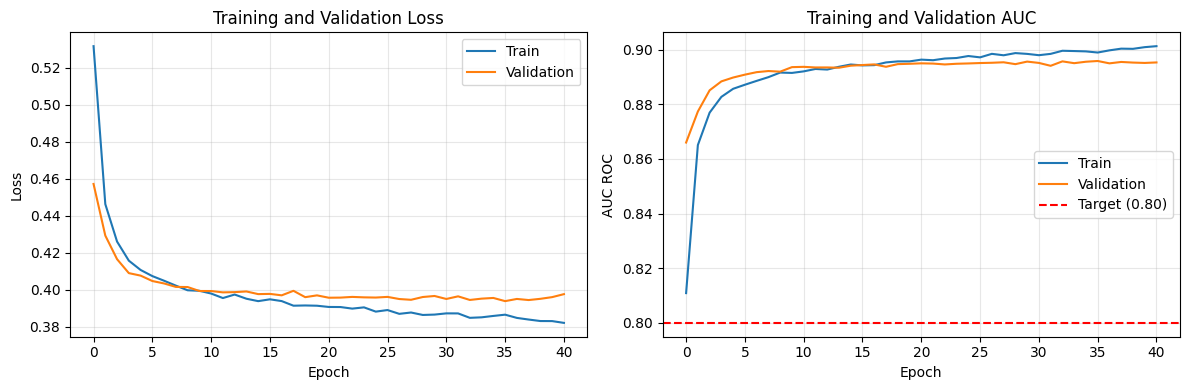

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AUC plot
axes[1].plot(history['train_auc'], label='Train')
axes[1].plot(history['val_auc'], label='Validation')
axes[1].axhline(y=0.80, color='r', linestyle='--', label='Target (0.80)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC ROC')
axes[1].set_title('Training and Validation AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Test Set Evaluation

In [21]:
# Evaluate on test set
test_loss, test_auc, y_pred_proba, y_true = evaluate(model, test_loader, criterion, device)

# Binary predictions at 0.5 threshold
y_pred = (y_pred_proba >= 0.5).astype(int)

print("="*50)
print("TEST SET RESULTS")
print("="*50)

TEST SET RESULTS


In [22]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"\nAUC ROC:   {test_auc:.4f}  {'PASS' if test_auc > 0.80 else 'FAIL'} (target > 0.80)")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")


AUC ROC:   0.8889  PASS (target > 0.80)
Accuracy:  0.8126
Precision: 0.8824
Recall:    0.7443
F1 Score:  0.8075


In [23]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print("                 Predicted")
print("                 Not-Risk  At-Risk")
print(f"Actual Not-Risk    {cm[0,0]:5d}    {cm[0,1]:5d}")
print(f"Actual At-Risk     {cm[1,0]:5d}    {cm[1,1]:5d}")


Confusion Matrix:
                 Predicted
                 Not-Risk  At-Risk
Actual Not-Risk     2052      256
Actual At-Risk       660     1921


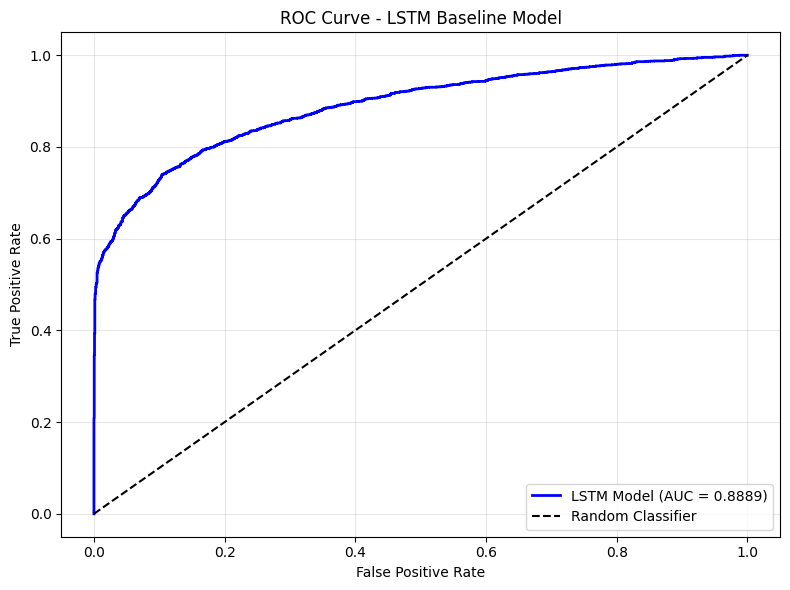

In [24]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'LSTM Model (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LSTM Baseline Model')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Save Model and Predictions

In [25]:
# Save model
model_path = MODEL_DIR / 'lstm_baseline.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'temporal_scaler_mean': temporal_scaler.mean_,
    'temporal_scaler_scale': temporal_scaler.scale_,
    'static_scaler_mean': static_scaler.mean_,
    'static_scaler_scale': static_scaler.scale_,
    'model_config': {
        'temporal_input_size': n_temp_features,
        'static_input_size': X_static.shape[1],
        'lstm_hidden_size': 64,
        'static_hidden_size': 32,
        'dropout': 0.3
    },
    'best_val_auc': best_val_auc,
    'test_auc': test_auc
}, model_path)

print(f"Model saved to: {model_path}")

Model saved to: ../models/lstm_baseline.pt


In [26]:
# Create predictions dataframe with protected attributes for fairness analysis
test_student_keys = student_keys[test_idx]
test_protected = protected_attrs.iloc[test_idx].reset_index(drop=True)

predictions_df = pd.DataFrame({
    'student_key': test_student_keys,
    'y_true': y_true,
    'y_pred_proba': y_pred_proba,
    'y_pred': y_pred
})

# Add protected attributes
predictions_df = pd.concat([predictions_df, test_protected], axis=1)

print(f"Predictions dataframe shape: {predictions_df.shape}")
print(f"Columns: {list(predictions_df.columns)}")

Predictions dataframe shape: (4889, 9)
Columns: ['student_key', 'y_true', 'y_pred_proba', 'y_pred', 'gender', 'region', 'imd_band_imputed', 'age_band', 'disability']


In [27]:
# Save predictions
predictions_path = DATA_DIR / 'predictions_baseline.csv'
predictions_df.to_csv(predictions_path, index=False)

print(f"Predictions saved to: {predictions_path}")

Predictions saved to: ../data/processed/predictions_baseline.csv


In [28]:
# Quick fairness preview: AUC by protected attribute
print("\n" + "="*50)
print("FAIRNESS PREVIEW: AUC by Protected Attribute")
print("="*50)

for attr in protected_cols:
    print(f"\n{attr}:")
    for group in predictions_df[attr].unique():
        mask = predictions_df[attr] == group
        if mask.sum() > 10:  # Only if enough samples
            group_auc = roc_auc_score(
                predictions_df.loc[mask, 'y_true'],
                predictions_df.loc[mask, 'y_pred_proba']
            )
            print(f"  {group}: AUC = {group_auc:.4f} (n={mask.sum()})")


FAIRNESS PREVIEW: AUC by Protected Attribute

gender:
  M: AUC = 0.8965 (n=2646)
  F: AUC = 0.8795 (n=2243)

region:
  Yorkshire Region: AUC = 0.8697 (n=316)
  South West Region: AUC = 0.9096 (n=369)
  North Western Region: AUC = 0.9246 (n=457)
  East Midlands Region: AUC = 0.8586 (n=344)
  Scotland: AUC = 0.8884 (n=516)
  South Region: AUC = 0.9024 (n=438)
  East Anglian Region: AUC = 0.8749 (n=484)
  South East Region: AUC = 0.9066 (n=347)
  Wales: AUC = 0.8792 (n=294)
  London Region: AUC = 0.8895 (n=476)
  West Midlands Region: AUC = 0.8637 (n=393)
  North Region: AUC = 0.9008 (n=274)
  Ireland: AUC = 0.8162 (n=181)

imd_band_imputed:
  50-60%: AUC = 0.8757 (n=458)
  60-70%: AUC = 0.8715 (n=446)
  30-40%: AUC = 0.8830 (n=518)
  70-80%: AUC = 0.8884 (n=436)
  10-20: AUC = 0.8989 (n=632)
  80-90%: AUC = 0.8659 (n=414)
  20-30%: AUC = 0.8915 (n=520)
  0-10%: AUC = 0.8925 (n=568)
  90-100%: AUC = 0.8596 (n=375)
  40-50%: AUC = 0.9140 (n=522)

age_band:
  35-55: AUC = 0.8786 (n=1447)
 

## Summary

This notebook established a baseline LSTM model for predicting at-risk students.

**Key Results:**
- Model architecture: LSTM (64 units) + Static features fusion
- Test AUC ROC: See above
- Predictions saved with protected attributes for fairness analysis

**Next Steps:**
1. Fairness analysis using AIF360
2. Implement bias mitigation techniques
3. Compare fairness-performance trade-offs